In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [6]:
df=pd.read_csv("customer_segmentation_data.csv")

In [7]:
print(df.head())
 #view Dataset

   id  age  gender  income  spending_score  membership_years  \
0   1   38  Female   99342              90                 3   
1   2   21  Female   78852              60                 2   
2   3   60  Female  126573              30                 2   
3   4   40   Other   47099              74                 9   
4   5   65  Female  140621              21                 3   

   purchase_frequency preferred_category  last_purchase_amount  
0                  24          Groceries                113.53  
1                  42             Sports                 41.93  
2                  28           Clothing                424.36  
3                   5      Home & Garden                991.93  
4                  25        Electronics                347.08  


In [8]:
#Check Dataset Information
print(df.info)

<bound method DataFrame.info of        id  age  gender  income  spending_score  membership_years  \
0       1   38  Female   99342              90                 3   
1       2   21  Female   78852              60                 2   
2       3   60  Female  126573              30                 2   
3       4   40   Other   47099              74                 9   
4       5   65  Female  140621              21                 3   
..    ...  ...     ...     ...             ...               ...   
995   996   57    Male  112170              57                 6   
996   997   23   Other   65337              76                10   
997   998   23    Male  113097              40                 5   
998   999   22  Female  113695              63                 7   
999  1000   36  Female   90420               7                 2   

     purchase_frequency preferred_category  last_purchase_amount  
0                    24          Groceries                113.53  
1                

In [ ]:
#check missing value
print(df.isnull().sum())

id                      0
age                     0
gender                  0
income                  0
spending_score          0
membership_years        0
purchase_frequency      0
preferred_category      0
last_purchase_amount    0
dtype: int64


In [9]:
X = df[['income', 'spending_score', 'purchase_frequency']]

In [10]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

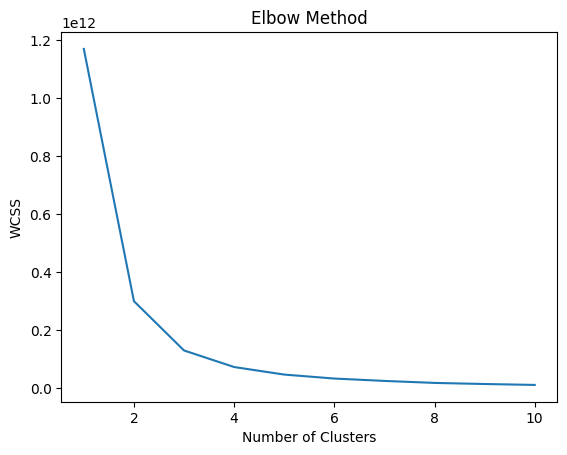

In [11]:
import matplotlib.pyplot as plt

plt.plot(range(1,11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


In [12]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X)

In [15]:
print(df.head(1
              ))

   id  age  gender  income  spending_score  membership_years  \
0   1   38  Female   99342              90                 3   

   purchase_frequency preferred_category  last_purchase_amount  Cluster  
0                  24          Groceries                113.53        2  


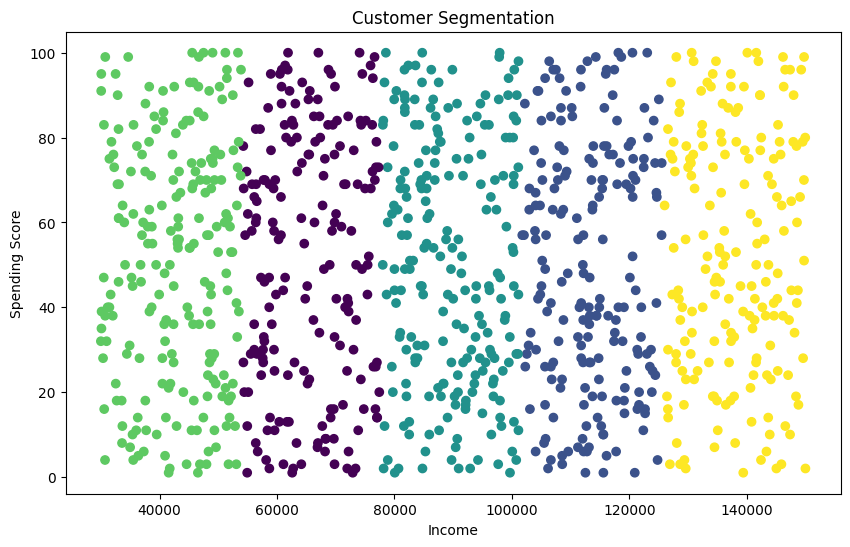

In [16]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['income'],
    df['spending_score'],
    c=df['Cluster']
)

plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")

plt.show()